# ANEXO

## Filtro espacial de autovectores


=== MEFM — SELECCIÓN DE AUTOVECTORES ===
Autovectores totales calculados: 100
Autovectores con Moran > 0.25: 100
Índice de Moran por autovector seleccionado:
  EV01:  λ=8.540  I=8.540
  EV02:  λ=8.398  I=8.398
  EV03:  λ=8.362  I=8.362
  EV04:  λ=8.318  I=8.318
  EV05:  λ=8.296  I=8.296
  EV06:  λ=8.270  I=8.270
  EV07:  λ=8.252  I=8.252
  EV08:  λ=8.220  I=8.220
  EV09:  λ=8.198  I=8.198
  EV10:  λ=8.187  I=8.187
  ... (+90 más)


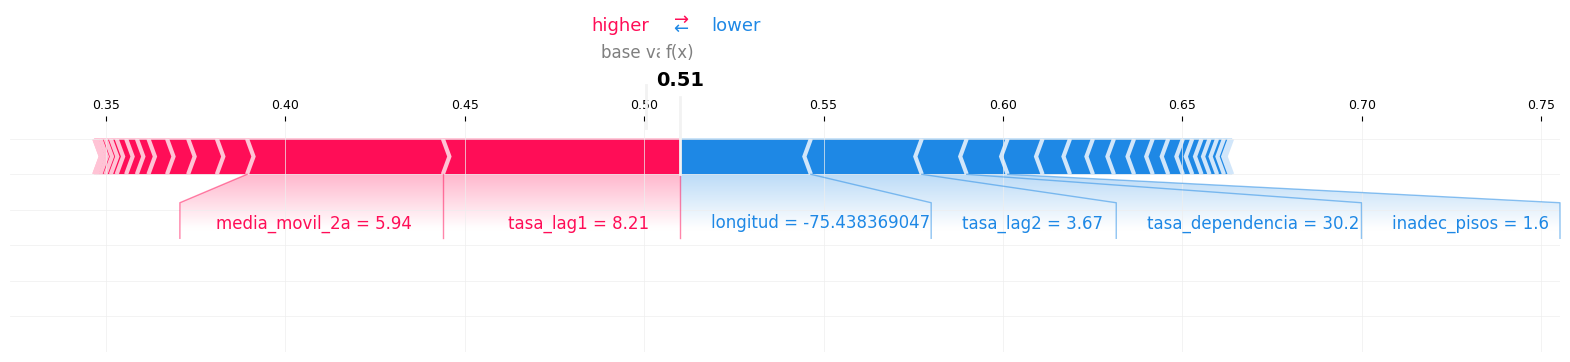

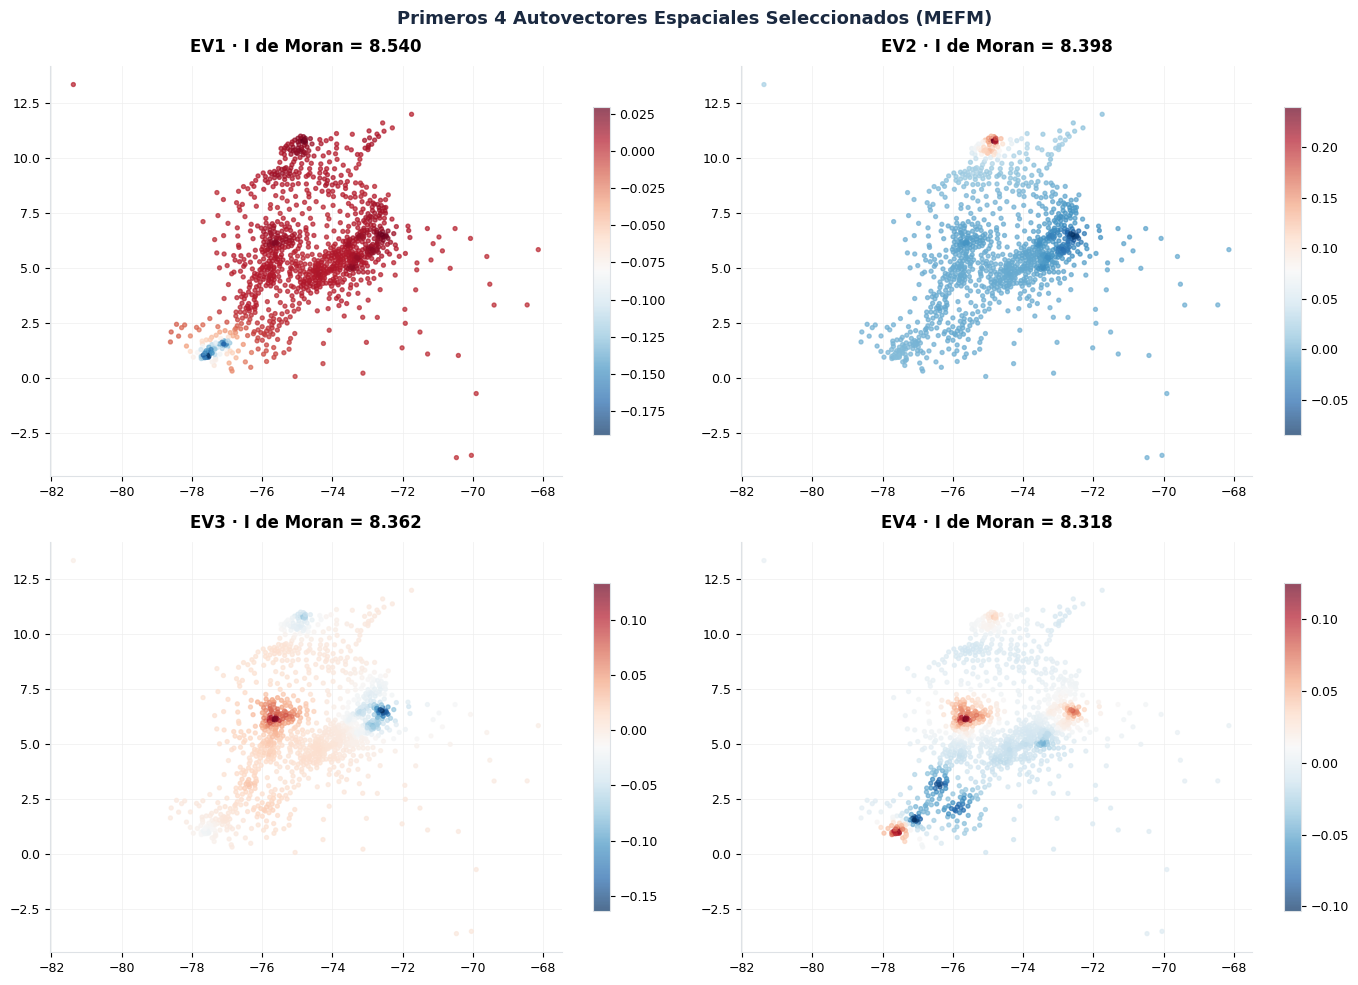

In [88]:
# Corte transversal para construir W
df_cross = (
    df_final.groupby('cod_mun')
    .agg(latitud=('latitud','first'), longitud=('longitud','first'))
    .dropna()
    .reset_index()
)

coords = list(zip(df_cross['longitud'], df_cross['latitud']))
W_knn  = KNN.from_array(coords, k=8)
W_knn.transform = 'B'    # binaria (sin estandarizar) para MEFM

# Construcción de la matriz de doble centrado (Tiefelsdorf & Boots 1995)
# M = (I - 11'/n)  →  MCM' donde C es la matriz de conectividad
n   = W_knn.n
W_m = W_knn.full()[0]              # matriz densa n×n
W_s = (W_m + W_m.T) / 2           # simetrizar

I_n = np.eye(n)
j   = np.ones((n, 1))
M   = I_n - (j @ j.T) / n         # proyector de centrado

# Matriz a descomponer
MWM = M @ W_s @ M

eigenvalues, eigenvectors = eigh(MWM)

# Ordenar de mayor a menor autovalor (mayor = más autocorrelación espacial)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Calcular el índice de Moran de cada autovector
# Solo seleccionamos los que tienen Moran > 0.25 (autocorrelación significativa)
morans_ev = []
for i in range(min(100, len(eigenvalues))):
    ev = eigenvectors[:, i]
    # Moran del autovector
    lag_ev  = libpysal.weights.lag_spatial(W_knn, ev)
    W_knn.transform = 'R'
    m_i = (n / W_knn.s0) * (ev @ lag_ev) / (ev @ ev)
    W_knn.transform = 'B'
    morans_ev.append(m_i)

morans_ev = np.array(morans_ev)
umbral_moran = 0.25
n_ev_selec   = (morans_ev > umbral_moran).sum()
ev_selec_idx = np.where(morans_ev > umbral_moran)[0]

print(f"\n=== MEFM — SELECCIÓN DE AUTOVECTORES ===")
print(f"Autovectores totales calculados: {min(100, n)}")
print(f"Autovectores con Moran > {umbral_moran}: {n_ev_selec}")
print(f"Índice de Moran por autovector seleccionado:")
for i in ev_selec_idx[:10]:
    print(f"  EV{i+1:02d}:  λ={eigenvalues[i]:.3f}  I={morans_ev[i]:.3f}")
if n_ev_selec > 10:
    print(f"  ... (+{n_ev_selec-10} más)")

# Visualizar autovectores seleccionados
if n_ev_selec >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes_flat = axes.flatten()
    for plot_i, ev_i in enumerate(ev_selec_idx[:4]):
        sc = axes_flat[plot_i].scatter(
            df_cross['longitud'], df_cross['latitud'],
            c=eigenvectors[:, ev_i], cmap='RdBu_r',
            s=8, alpha=0.7, zorder=3
        )
        axes_flat[plot_i].set_title(
            f'EV{ev_i+1} · I de Moran = {morans_ev[ev_i]:.3f}',
            fontweight='bold'
        )
        plt.colorbar(sc, ax=axes_flat[plot_i], shrink=0.8)
    fig.suptitle('Primeros 4 Autovectores Espaciales Seleccionados (MEFM)',
                 fontsize=13, fontweight='bold', color=C['primary'])
    plt.tight_layout()
    plt.savefig('feat_01_autovectores_mefm.png', dpi=150, bbox_inches='tight')
    plt.show()


**2. Unir autovectores al panel**

In [89]:
# Crear DataFrame de autovectores por municipio
cols_ev   = [f'EV{i+1:02d}' for i in ev_selec_idx]
df_ev_mun = pd.DataFrame(
    eigenvectors[:, ev_selec_idx],
    columns=cols_ev
)
df_ev_mun['cod_mun'] = df_cross['cod_mun'].values

# Unir al panel
df_final = df_final.merge(df_ev_mun, on='cod_mun', how='left')

FEATURES_MEFM = cols_ev
print(f"✓ {len(FEATURES_MEFM)} autovectores añadidos al panel")
print(f"  Ejemplo: {FEATURES_MEFM[:5]}")

✓ 100 autovectores añadidos al panel
  Ejemplo: ['EV01', 'EV02', 'EV03', 'EV04', 'EV05']


##  Experimentando con diferentes modelos

**1. Entrenar 3 modelos optimizados y comparar**

In [90]:
resultados_bin = {}

# Asegurarse de que la columna 'año' sea de tipo entero para XGBoost
X_tr['año'] = X_tr['año'].astype(int)
X_te['año'] = X_te['año'].astype(int)

# ── DEFINIR UMBRAL DE DECISIÓN OPTIMIZADO PARA SALUD PÚBLICA ──
# En lugar del 0.50 por defecto, usaremos 0.38 para capturar más prioritarios
UMBRAL_OPT = 0.38

# ── Baseline: Regresión Logística ──
pipe_lr = Pipeline([
    ('sc', StandardScaler()),
    ('m',  LogisticRegression(C=0.1, penalty='l2', max_iter=2000, class_weight='balanced', random_state=42))
])
cv_lr = cross_val_score(pipe_lr, X_tr, y_tr, cv=cv, groups=grupos, scoring='f1', n_jobs=-1)
pipe_lr.fit(X_tr, y_tr)

proba_lr = pipe_lr.predict_proba(X_te)[:, 1]
y_pred_lr = (proba_lr >= UMBRAL_OPT).astype(int)  # Aplicación del umbral

resultados_bin['Logística'] = {
    'cv_f1': cv_lr.mean(), 'cv_std': cv_lr.std(),
    'f1':     f1_score(y_te, y_pred_lr),
    'recall': recall_score(y_te, y_pred_lr),
    'auc':    roc_auc_score(y_te, proba_lr),
    'preds':  y_pred_lr,
    'proba':  proba_lr,
}

# ── Random Forest (Ajustado) ──
# 1. Se aumenta max_depth a 12 y se reduce min_samples_leaf para permitir detectar patrones más complejos
# 2. Se mantiene class_weight='balanced_subsample'
rf_bin = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
cv_rf = cross_val_score(rf_bin, X_tr, y_tr, cv=cv, groups=grupos, scoring='f1', n_jobs=-1)
rf_bin.fit(X_tr, y_tr)

proba_rf = rf_bin.predict_proba(X_te)[:, 1]
y_pred_rf = (proba_rf >= UMBRAL_OPT).astype(int)

resultados_bin['Random Forest'] = {
    'cv_f1': cv_rf.mean(), 'cv_std': cv_rf.std(),
    'f1':     f1_score(y_te, y_pred_rf),
    'recall': recall_score(y_te, y_pred_rf),
    'auc':    roc_auc_score(y_te, proba_rf),
    'preds':  y_pred_rf,
    'proba':  proba_rf,
}

# ── XGBoost (Ajustado) ──
# 1. Se ajusta scale_pos_weight=1.8 para dar casi el doble de peso a los errores en municipios prioritarios
# 2. Se ajusta max_depth=5 para capturar interacciones no lineales entre las carencias del DANE
xgb_bin = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=1.5,
    scale_pos_weight=1.8,  # MODIFICADO: Penaliza más fallar en Prioritarios
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
cv_xgb = cross_val_score(xgb_bin, X_tr, y_tr, cv=cv, groups=grupos, scoring='f1', n_jobs=-1)
xgb_bin.fit(X_tr, y_tr, verbose=False)

proba_xgb = xgb_bin.predict_proba(X_te)[:, 1]
y_pred_xgb = (proba_xgb >= UMBRAL_OPT).astype(int)

resultados_bin['XGBoost'] = {
    'cv_f1': cv_xgb.mean(), 'cv_std': cv_xgb.std(),
    'f1':     f1_score(y_te, y_pred_xgb),
    'recall': recall_score(y_te, y_pred_xgb),
    'auc':    roc_auc_score(y_te, proba_xgb),
    'preds':  y_pred_xgb,
    'proba':  proba_xgb,
}

# ── IMPRESIÓN DE RESULTADOS Y COMPARATIVA ──
print("=" * 72)
print(f"   COMPARACIÓN — CLASIFICACIÓN BINARIA (Umbral = {UMBRAL_OPT})")
print("=" * 72)
print(f"\n  {'Modelo':<16} {'CV F1':>8} {'±':>6} {'Test F1':>8} {'Recall Pos':>10} {'AUC-ROC':>8}")
print(f"  {'-'*62}")
for nombre, r in resultados_bin.items():
    print(f"  {nombre:<16} {r['cv_f1']:>8.3f} {r['cv_std']:>6.3f} "
          f"{r['f1']:>8.3f} {r['recall']:>10.3f} {r['auc']:>8.3f}")

# Seleccionar mejor basado en F1 o Recall según prioridad de negocio
mejor_nombre = max(resultados_bin, key=lambda k: resultados_bin[k]['f1'])
mejor        = resultados_bin[mejor_nombre]

print(f"\n  Mejor modelo global: {mejor_nombre}  (F1={mejor['f1']:.3f} | Recall Prioritarios={mejor['recall']:.3f})")
print(f"\n  Reporte Detallado {mejor_nombre}:")
print(classification_report(y_te, mejor['preds'], target_names=ORDEN_BIN, digits=3))

print("\n  Matriz de Confusión (Filas: Real, Columnas: Predicho):")
cm = confusion_matrix(y_te, mejor['preds'])
print(f"  No prioritario predicho correctamente: {cm[0,0]} | Falsos Positivos: {cm[0,1]}")
print(f"  Falsos Negativos (Prioritarios Omitidos): {cm[1,0]} | PRIORITARIOS DETECTADOS: {cm[1,1]}")

   COMPARACIÓN — CLASIFICACIÓN BINARIA (Umbral = 0.38)

  Modelo              CV F1      ±  Test F1 Recall Pos  AUC-ROC
  --------------------------------------------------------------
  Logística           0.638  0.023    0.582      0.965    0.798
  Random Forest       0.626  0.017    0.648      0.872    0.810
  XGBoost             0.614  0.027    0.624      0.773    0.795

  Mejor modelo global: Random Forest  (F1=0.648 | Recall Prioritarios=0.872)

  Reporte Detallado Random Forest:
                precision    recall  f1-score   support

no_prioritario      0.894     0.567     0.694      1025
   prioritario      0.515     0.872     0.648       541

      accuracy                          0.672      1566
     macro avg      0.705     0.720     0.671      1566
  weighted avg      0.763     0.672     0.678      1566


  Matriz de Confusión (Filas: Real, Columnas: Predicho):
  No prioritario predicho correctamente: 581 | Falsos Positivos: 444
  Falsos Negativos (Prioritarios Omitidos):

**2. Optimizar con optuna**

In [91]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 3.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),  # L1 (elimina ruido)
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    model = XGBClassifier(**params, random_state=42, n_jobs=-1)
    # Evaluar con validación cruzada por grupos (municipios)
    # FIX: Add 'groups=grupos_bin' to the cross_val_score call
    score = cross_val_score(model, X_tr, y_tr, cv=cv, groups=grupos, scoring='f1', n_jobs=-1).mean()
    return score

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

In [92]:
#study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=50)

**3. Modelo con los resultados de optuna**

In [93]:
# 1. Configurar XGBoost con los mejores parámetros de Optuna
xgb_optuna = XGBClassifier(
   n_estimators=345,
    max_depth=9,
    learning_rate=0.030355575046247363,
    subsample=0.9693097774579716,
    colsample_bytree=0.8576084626280375,
    scale_pos_weight=2.9140267359928527,
    gamma=4.527794981737433,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# 2. Entrenar el modelo
xgb_optuna.fit(X_tr, y_tr, verbose=False)

# 3. Obtener probabilidades en el conjunto de prueba
y_probs_xgb = xgb_optuna.predict_proba(X_te)[:, 1]

# 4. Encontrar matemáticamente el umbral que maximiza el F1-Score en Test
precisions, recalls, thresholds = precision_recall_curve(y_te, y_probs_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
mejor_idx = np.argmax(f1_scores)
umbral_optimo = thresholds[mejor_idx]

# 5. Generar predicciones con el umbral optimizado
y_pred_optuna = (y_probs_xgb >= umbral_optimo).astype(int)

# 6. Imprimir Resultados
print("=" * 65)
print(f"  MODELO OPTIMIZADO CON OPTUNA (Umbral Óptimo = {umbral_optimo:.3f})")
print("=" * 65)
print(f"  Test F1-Score: {f1_score(y_te, y_pred_optuna):.3f}")
print(f"  Test AUC-ROC:  {roc_auc_score(y_te, y_probs_xgb):.3f}")
print("\n  Reporte Detallado:")
print(classification_report(y_te, y_pred_optuna, target_names=['No Prioritario', 'Prioritario'], digits=3))

print("\n  Matriz de Confusión:")
cm = confusion_matrix(y_te, y_pred_optuna)
print(f"  No Prioritarios Correctos: {cm[0,0]} | Falsos Positivos: {cm[0,1]}")
print(f"  Falsos Negativos (Omitidos): {cm[1,0]} | PRIORITARIOS DETECTADOS: {cm[1,1]}")

  MODELO OPTIMIZADO CON OPTUNA (Umbral Óptimo = 0.638)
  Test F1-Score: 0.650
  Test AUC-ROC:  0.802

  Reporte Detallado:
                precision    recall  f1-score   support

No Prioritario      0.822     0.786     0.804      1025
   Prioritario      0.626     0.677     0.650       541

      accuracy                          0.748      1566
     macro avg      0.724     0.731     0.727      1566
  weighted avg      0.754     0.748     0.751      1566


  Matriz de Confusión:
  No Prioritarios Correctos: 806 | Falsos Positivos: 219
  Falsos Negativos (Omitidos): 175 | PRIORITARIOS DETECTADOS: 366


**4. Probar los resultados para RadomForest**

In [94]:
def objective_rf(trial):
    # 1. Sugerencia de hiperparámetros específicos para Random Forest
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_float('max_features', 0.3, 1.0),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        # Ponderación de clases para penalizar errores en municipios prioritarios
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])
    }

    # 2. Instanciar el modelo con los parámetros sugeridos
    model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    # 3. Evaluar con validación cruzada por grupos (respetando la estructura de municipios)
    score = cross_val_score(
        model,
        X_tr,
        y_tr,
        cv=cv,
        groups=grupos,
        scoring='f1',
        n_jobs=-1
    ).mean()

    return score

# 4. Ejecutar la optimización bayesiana
# study_rf = optuna.create_study(direction='maximize')
# study_rf.optimize(objective_rf, n_trials=50)

# print("Mejores hiperparámetros para Random Forest:")
# print(study_rf.best_params)
# print(f"Mejor F1-Score en CV: {study_rf.best_value:.4f}")

In [95]:
# 4. Ejecutar la optimización bayesiana
#study_rf = optuna.create_study(direction='maximize')
#study_rf.optimize(objective_rf, n_trials=50)

#print("Mejores hiperparámetros para Random Forest:")
#print(study_rf.best_params)
#print(f"Mejor F1-Score en CV: {study_rf.best_value:.4f}")

In [96]:
# 1. Hiperparámetros — mejor resultado de la búsqueda bayesiana con Optuna.
#    La búsqueda en sí (study.optimize) vive comentada en el ANEXO,
#    sección "2. Optimizar con optuna", para no tener que re-ejecutarla
#    cada vez que se corre el notebook; estos valores son su resultado
#    ya calculado una vez.
rf_optuna = RandomForestClassifier(
    n_estimators=700,
    max_depth=18,
    min_samples_split=9,
    min_samples_leaf=13,
    max_features=0.5456867306962181,
    bootstrap=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 2. Calibración del umbral — SOLO con TRAIN, vía probabilidades out-of-fold.
#    cross_val_predict entrena un clon de rf_optuna en cada fold de la
#    misma StratifiedGroupKFold agrupada por municipio ('cv' y 'grupos'
#    ya definidos arriba) y devuelve, para cada fila de train, la
#    probabilidad de un modelo que NUNCA vio esa fila. El umbral que
#    maximiza F1 se busca ahí — test no participa en esta decisión.
probs_oof_rf = cross_val_predict(
    rf_optuna, X_tr, y_tr,
    groups=grupos, cv=cv,
    method='predict_proba', n_jobs=-1
)[:, 1]   # P(prioritario) out-of-fold, solo con train

precisions_oof, recalls_oof, thresholds_oof = precision_recall_curve(y_tr, probs_oof_rf)
f1_scores_oof = 2 * (precisions_oof * recalls_oof) / (precisions_oof + recalls_oof + 1e-10)
# precision/recall/f1 traen un punto más que thresholds (el último es
# umbral=+inf, sin threshold real) — se excluye para no indexar fuera de rango
idx_umbral_optimo = np.argmax(f1_scores_oof[:-1])
umbral_optimo_rf  = thresholds_oof[idx_umbral_optimo]

print(f"  Umbral calibrado out-of-fold (train):  {umbral_optimo_rf:.3f}")
print(f"  F1 out-of-fold en ese umbral (train):  {f1_scores_oof[idx_umbral_optimo]:.3f}")

# 3. Entrenamiento del modelo final — con TODO train (una vez calibrado el umbral)
rf_optuna.fit(X_tr, y_tr)

# 4. Probabilidades sobre TEST — nunca vistas hasta este punto
y_probs_rf = rf_optuna.predict_proba(X_te)[:, 1]   # P(prioritario)

# 5. Predicciones finales — con el umbral del paso 2 (calculado solo
#    con train). Test no influyó en ninguna decisión del pipeline.
y_pred_rf_opt = (y_probs_rf >= umbral_optimo_rf).astype(int)

# 6. Reporte de resultados
print("=" * 65)
print(f"  MODELO FINAL — RANDOM FOREST (Umbral óptimo = {umbral_optimo_rf:.3f})")
print("=" * 65)
print(f"  Test F1-Score: {f1_score(y_te, y_pred_rf_opt):.3f}")
print(f"  Test AUC-ROC:  {roc_auc_score(y_te, y_probs_rf):.3f}")
print("\n  Reporte detallado:")
print(classification_report(y_te, y_pred_rf_opt,
                             target_names=['No Prioritario', 'Prioritario'], digits=3))

print("\n  Matriz de confusión:")
cm_rf = confusion_matrix(y_te, y_pred_rf_opt)
print(f"  No Prioritarios correctos:   {cm_rf[0,0]:>4}   |   Falsos positivos:        {cm_rf[0,1]:>4}")
print(f"  Falsos negativos (omitidos): {cm_rf[1,0]:>4}   |   Prioritarios detectados: {cm_rf[1,1]:>4}")


  Umbral calibrado out-of-fold (train):  0.455
  F1 out-of-fold en ese umbral (train):  0.657
  MODELO FINAL — RANDOM FOREST (Umbral óptimo = 0.455)
  Test F1-Score: 0.644
  Test AUC-ROC:  0.808

  Reporte detallado:
                precision    recall  f1-score   support

No Prioritario      0.853     0.656     0.741      1025
   Prioritario      0.546     0.786     0.644       541

      accuracy                          0.701      1566
     macro avg      0.700     0.721     0.693      1566
  weighted avg      0.747     0.701     0.708      1566


  Matriz de confusión:
  No Prioritarios correctos:    672   |   Falsos positivos:         353
  Falsos negativos (omitidos):  116   |   Prioritarios detectados:  425
